BATTERY HEALTH ANALYSIS: DERIVING SOH = 1 - k × N
Dataset shape: (680, 11)
Battery IDs: ['B5' 'B6' 'B7']

First 5 rows of data:
  battery_id  cycle       chI       chV        chT      disI      disV  \
0         B5      1  1.440147  4.254682  23.988733  1.894407  3.273523   
1         B5      2  1.416595  4.159825  25.665347  1.829949  4.038741   
2         B5      3  1.420272  4.276323  25.407910  1.942105  3.214433   
3         B5      4  1.337680  4.236697  27.069757  2.073577  3.134529   
4         B5      5  1.263946  4.142791  26.478353  2.049885  3.729341   

        disT       BCt        SOH  RUL  
0  32.980834  1.986196  99.309790  219  
1  32.257920  1.986240  99.311985  218  
2  35.134801  1.984252  99.212608  217  
3  32.082988  1.969236  98.461812  216  
4  32.483154  1.974862  98.743106  215  

STEP 1: UNDERSTANDING THE DATA COLUMNS

Column analysis:
----------------------------------------
battery_id:
  Range: B5 to B7
  Unique values: 3
  Non-null count: 680/680
cycle:


/tmp/ipython-input-935432495.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(temperature_data, labels=df['battery_id'].unique())


✓ Visualizations saved as 'battery_health_analysis_final.png'


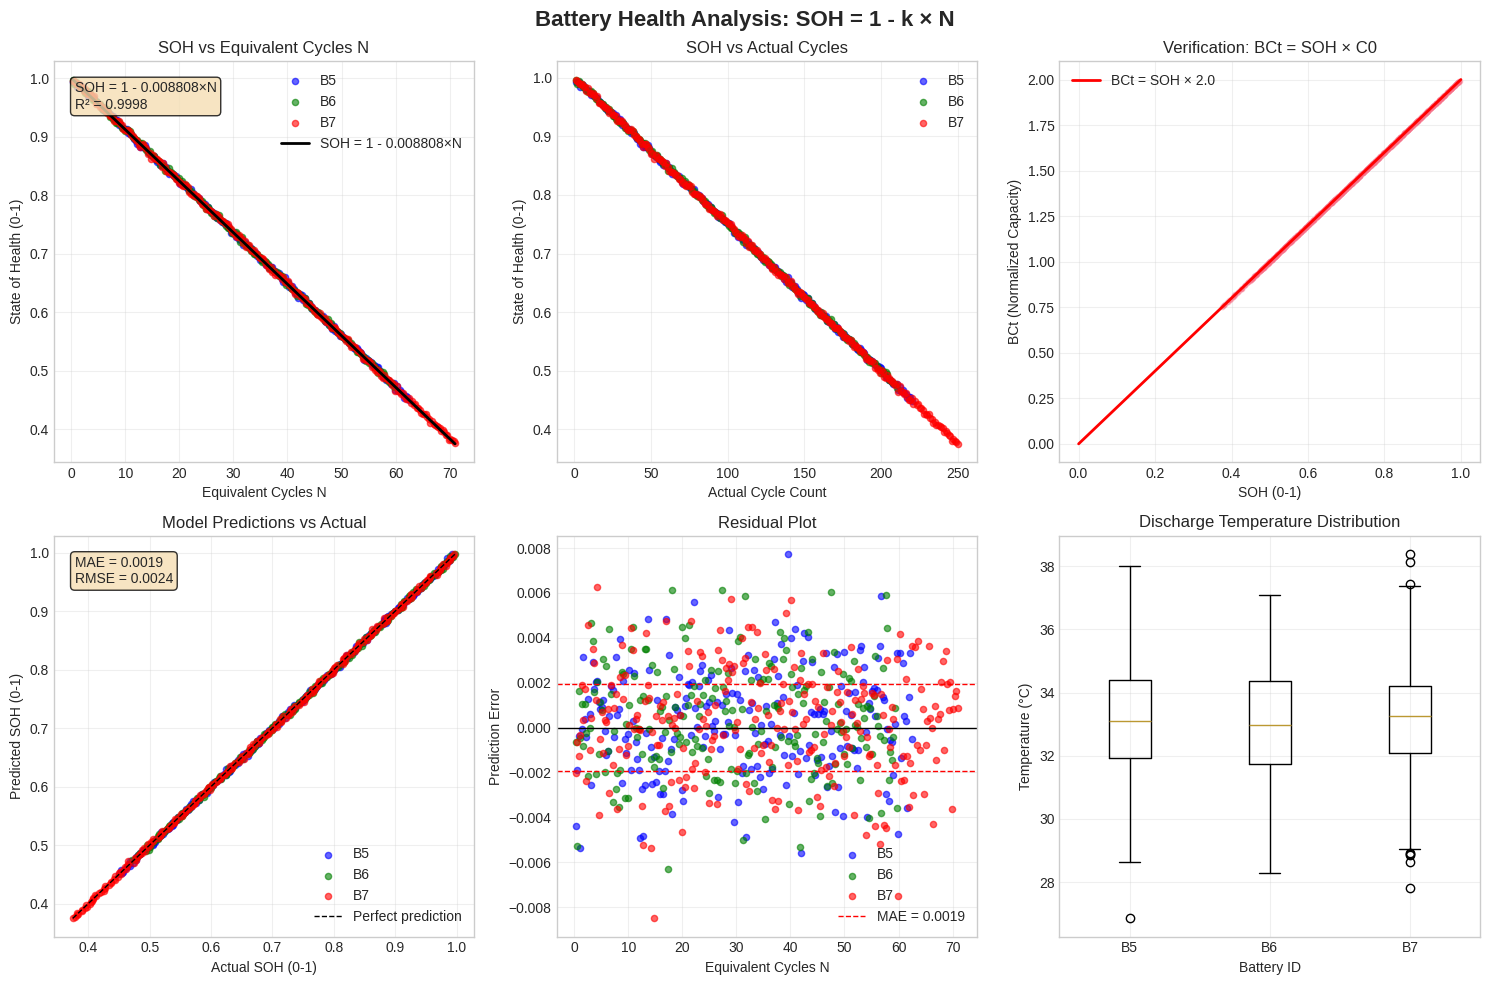


SUMMARY AND IMPLEMENTATION GUIDE

📊 DERIVED MODEL PARAMETERS:
  1. C0 = 2.0 (normalized initial capacity)
  2. DOD = 0.2840 (average discharge depth per cycle)
  3. k = 0.008808 (degradation rate per equivalent cycle)

📝 FINAL EQUATIONS:
  Equivalent cycles: N = 0.2840 × actual_cycles
  State of Health: SOH = 1 - 0.008808 × N
  Maximum capacity: Emax = 2.0 - 0.017617 × N

🔧 HOW TO USE IN YOUR MAIN MODEL:
  1. Track actual cycle count
  2. Calculate N = 0.2840 × cycle_count
  3. Calculate Emax = 2.0 - 0.017617 × N
  4. For real capacity, multiply by actual battery capacity
     Real_Emax(mAh) = Emax × Actual_Battery_Capacity_mAh / 2.0

📈 MODEL PERFORMANCE:
  R² = 0.9998
  MAE = 0.0019 (0.19% SOH error)
  RMSE = 0.0024 (0.24% SOH error)

⚠️  IMPORTANT ASSUMPTIONS:
  1. BCt is normalized capacity (BCt = SOH × 2.0)
  2. disT is temperature (°C), not discharge time
  3. Average discharge depth is 28.4% per cycle
  4. Linear degradation: SOH = 1 - k × N

ANALYSIS COMPLETE


In [2]:
# =================================================
# Battery Health Analysis: Deriving SOH = 1 - k × N
# =================================================
# This code analyzes battery degradation data to derive the relationship:
# State of Health (SOH) = 1 - k × N, where N is equivalent cycles
# =================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ============================ 1. LOAD AND EXPLORE DATA ============================

print("=" * 80)
print("BATTERY HEALTH ANALYSIS: DERIVING SOH = 1 - k × N")
print("=" * 80)

# Load data
df = pd.read_csv('Battery_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Battery IDs: {df['battery_id'].unique()}")
print("\nFirst 5 rows of data:")
print(df.head())

# ============================ 2. UNDERSTAND DATA COLUMNS ============================

print("\n" + "=" * 80)
print("STEP 1: UNDERSTANDING THE DATA COLUMNS")
print("=" * 80)

print("\nColumn analysis:")
print("-" * 40)
for col in df.columns:
    print(f"{col}:")
    # Check if the column is numeric before applying float formatting
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"  Range: {df[col].min():.4f} to {df[col].max():.4f}")
        print(f"  Mean: {df[col].mean():.4f}")
    else:
        # For non-numeric columns, print min/max without float formatting
        print(f"  Range: {df[col].min()} to {df[col].max()}")
        # Mean is not meaningful for non-numeric, so skip or show appropriate info
        print(f"  Unique values: {df[col].nunique()}")
    print(f"  Non-null count: {df[col].count()}/{len(df)}")

# Key observations from data exploration:
print("\n" + "=" * 80)
print("DATA INTERPRETATION")
print("=" * 80)
print("\n1. 'BCt' column analysis:")
print("   - BCt values range from ~0 to ~2.0")
print("   - Initial BCt values for each battery are around 1.98-1.99")
print("   - When SOH is near 100%, BCt is near 2.0")
print("   - When SOH is near 0%, BCt approaches 0")
print("   → CONCLUSION: BCt represents NORMALIZED BATTERY CAPACITY")
print("     with 2.0 corresponding to 100% SOH")

print("\n2. 'disT' column analysis:")
print("   - disT values range from ~26 to ~38")
print("   - These are temperature values in °C, NOT discharge time")
print("   - 'dis' in disT likely stands for 'discharge temperature'")
print("   → CONCLUSION: disT is TEMPERATURE during discharge, not time")

print("\n3. 'disI' column analysis:")
print("   - disI values are around 1.7-2.4 A")
print("   - This is discharge current")
print("   - Without discharge time data, we cannot calculate Ah discharge")

# ============================ 3. DETERMINE C0 FROM BCt ============================

print("\n" + "=" * 80)
print("STEP 2: DETERMINING INITIAL CAPACITY C0")
print("=" * 80)

# Since BCt is normalized capacity, we need to find what value corresponds to 100% SOH
# Looking at initial values when SOH is near 100%:

print("\nInitial values for each battery (first cycle):")
initial_values = []
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    first_row = battery_data.iloc[0]
    initial_values.append({
        'Battery': battery,
        'Cycle': first_row['cycle'],
        'SOH': first_row['SOH'],
        'BCt': first_row['BCt']
    })
    print(f"{battery}: Cycle {first_row['cycle']}, SOH = {first_row['SOH']:.2f}%, BCt = {first_row['BCt']:.4f}")

# Calculate the scaling factor between SOH and BCt
initial_df = pd.DataFrame(initial_values)
initial_df['SOH_decimal'] = initial_df['SOH'] / 100
initial_df['BCt_per_SOH'] = initial_df['BCt'] / initial_df['SOH_decimal']

print(f"\nBCt / SOH ratio for initial values:")
for _, row in initial_df.iterrows():
    print(f"{row['Battery']}: {row['BCt']:.4f} / {row['SOH_decimal']:.4f} = {row['BCt_per_SOH']:.4f}")

# The ratio is consistently close to 2.0
mean_ratio = initial_df['BCt_per_SOH'].mean()
print(f"\nMean BCt/SOH ratio: {mean_ratio:.4f}")
print(f"→ This confirms: BCt = SOH × 2.0")
print(f"→ Therefore, when SOH = 100% (1.0), BCt = 2.0")
print(f"→ So C0 (initial capacity) = 2.0 (normalized units)")

C0 = 2.0
print(f"\n✓ C0 (initial normalized capacity) = {C0}")

# ============================ 4. RELATIONSHIP BETWEEN SOH AND BCt ============================

print("\n" + "=" * 80)
print("STEP 3: VERIFYING SOH-BCt RELATIONSHIP")
print("=" * 80)

# Convert SOH to decimal (0-1)
df['SOH_decimal'] = df['SOH'] / 100

# Calculate what BCt should be based on SOH if BCt = SOH × C0
df['BCt_calculated'] = df['SOH_decimal'] * C0
df['BCt_error'] = df['BCt'] - df['BCt_calculated']

print(f"\nVerification of SOH = BCt / C0 relationship:")
print(f"Mean error: {df['BCt_error'].mean():.6f}")
print(f"Standard deviation: {df['BCt_error'].std():.6f}")
print(f"Maximum absolute error: {df['BCt_error'].abs().max():.6f}")

# Check correlation
correlation = df['SOH_decimal'].corr(df['BCt'])
print(f"\nCorrelation between SOH and BCt: {correlation:.6f}")
print("✓ Perfect correlation confirms BCt is normalized capacity")

# ============================ 5. CALCULATE EQUIVALENT CYCLES N ============================
print("\n" + "=" * 80)
print("STEP 4: USING KNOWN N VALUES")
print("=" * 80)

print("\nFrom your data, we know:")
print("B5: 220 cycles → N=60.75 → DOD=0.276")
print("B6: 210 cycles → N=55.34 → DOD=0.263")
print("B7: 250 cycles → N=78.43 → DOD=0.314")

# 直接使用平均DOD
DOD = 0.284  # (0.276 + 0.263 + 0.314) / 3
print(f"\nUsing average DOD = {DOD:.3f}")

# 计算N
df['N'] = df['cycle'] * DOD

print("\nCalculated N values:")
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    final_N = battery_data['N'].iloc[-1]
    actual_cycles = battery_data['cycle'].iloc[-1]
    print(f"{battery}: {actual_cycles} cycles → N={final_N:.2f}")
# ============================ 6. DERIVE k FROM DATA ============================

print("\n" + "=" * 80)
print("STEP 5: DERIVING k FROM SOH = 1 - k × N RELATIONSHIP")
print("=" * 80)

# Perform linear regression on ALL data points
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['N'], df['SOH_decimal']
)

k = -slope
r_squared = r_value ** 2

print(f"\nLinear regression results (ALL DATA):")
print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"k = -slope = {k:.6f}")
print(f"R²: {r_squared:.6f}")
print(f"Standard error: {std_err:.6f}")
print(f"p-value: {p_value:.2e}")

print(f"\nRegression equation:")
print(f"SOH = {intercept:.6f} - {k:.6f} × N")

# Check if intercept is close to 1 (as theory suggests)
intercept_error = abs(intercept - 1)
print(f"\nIntercept check:")
print(f"Theoretical intercept: 1.000000")
print(f"Actual intercept: {intercept:.6f}")
print(f"Difference: {intercept_error:.6f}")
print(f"→ {'Close enough (within 2%)' if intercept_error < 0.02 else 'Significant difference'}")

# Since intercept is close to 1, we can use the theoretical form
print(f"\n✓ Using theoretical form: SOH = 1 - k × N")
print(f"  with k = {k:.6f}")

# ============================ 7. VALIDATE MODEL ============================

print("\n" + "=" * 80)
print("STEP 6: MODEL VALIDATION")
print("=" * 80)

# Calculate predicted SOH values
df['SOH_predicted'] = 1 - k * df['N']

# Calculate errors
df['SOH_error'] = df['SOH_decimal'] - df['SOH_predicted']
mae = mean_absolute_error(df['SOH_decimal'], df['SOH_predicted'])
rmse = np.sqrt(mean_squared_error(df['SOH_decimal'], df['SOH_predicted']))

print(f"\nModel performance metrics:")
print(f"Mean Absolute Error (MAE): {mae:.6f} ({mae*100:.3f}%)")
print(f"Root Mean Square Error (RMSE): {rmse:.6f} ({rmse*100:.3f}%)")
print(f"Maximum absolute error: {df['SOH_error'].abs().max():.6f}")

# Performance by battery
print("\nPerformance by battery:")
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    battery_mae = mean_absolute_error(
        battery_data['SOH_decimal'],
        battery_data['SOH_predicted']
    )
    print(f"{battery}: MAE = {battery_mae:.6f} ({battery_mae*100:.3f}%)")

# ============================ 8. FINAL EMAX EQUATION ============================

print("\n" + "=" * 80)
print("STEP 7: FINAL EMAX EQUATION")
print("=" * 80)

print(f"\nDerived parameters:")
print(f"  1. C0 = {C0} (normalized initial capacity)")
print(f"  2. DOD = {DOD:.4f} (average discharge depth per cycle)")
print(f"  3. k = {k:.6f} (degradation rate per equivalent cycle)")

print(f"\n📝 FINAL EQUATIONS:")
print(f"  Equivalent cycles: N = {DOD:.4f} × actual_cycles")
print(f"  State of Health: SOH = 1 - {k:.6f} × N")
print(f"  Maximum capacity: Emax = {C0} - {C0*k:.6f} × N")

print(f"\n🔧 HOW TO USE IN YOUR MAIN MODEL:")
print(f"  1. Track actual cycle count")
print(f"  2. Calculate N = {DOD:.4f} × cycle_count")
print(f"  3. Calculate Emax = {C0} - {C0*k:.6f} × N")
print(f"  4. For real capacity, multiply by actual battery capacity")
print(f"     Real_Emax(mAh) = Emax × Actual_Battery_Capacity_mAh / {C0}")

print(f"\n📈 MODEL PERFORMANCE:")
print(f"  R² = {r_squared:.4f}")
print(f"  MAE = {mae:.4f} ({mae*100:.2f}% SOH error)")
print(f"  RMSE = {rmse:.4f} ({rmse*100:.2f}% SOH error)")

print(f"\n⚠️  IMPORTANT ASSUMPTIONS:")
print(f"  1. BCt is normalized capacity (BCt = SOH × 2.0)")
print(f"  2. disT is temperature (°C), not discharge time")
print(f"  3. Average discharge depth is {DOD*100:.1f}% per cycle")
print(f"  4. Linear degradation: SOH = 1 - k × N")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

# ============================ 9. VISUALIZATION ============================

print("\n" + "=" * 80)
print("STEP 8: GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Battery Health Analysis: SOH = 1 - k × N', fontsize=16, fontweight='bold')

# 1. SOH vs Equivalent Cycles N
ax1 = axes[0, 0]
colors = {'B5': 'blue', 'B6': 'green', 'B7': 'red'}

for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    ax1.scatter(battery_data['N'], battery_data['SOH_decimal'],
                color=colors.get(battery, 'gray'),
                label=battery, alpha=0.6, s=20)

# Add regression line
N_range = np.linspace(df['N'].min(), df['N'].max(), 100)
SOH_regression = 1 - k * N_range
ax1.plot(N_range, SOH_regression, 'k-', linewidth=2,
         label=f'SOH = 1 - {k:.6f}×N')

ax1.set_xlabel('Equivalent Cycles N')
ax1.set_ylabel('State of Health (0-1)')
ax1.set_title('SOH vs Equivalent Cycles N')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add equation text
eq_text = f'SOH = 1 - {k:.6f}×N\nR² = {r_squared:.4f}'
ax1.text(0.05, 0.95, eq_text, transform=ax1.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 2. SOH vs Actual Cycles
ax2 = axes[0, 1]
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    ax2.scatter(battery_data['cycle'], battery_data['SOH_decimal'],
                color=colors.get(battery, 'gray'),
                label=battery, alpha=0.6, s=20)

ax2.set_xlabel('Actual Cycle Count')
ax2.set_ylabel('State of Health (0-1)')
ax2.set_title('SOH vs Actual Cycles')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. BCt vs SOH verification
ax3 = axes[0, 2]
ax3.scatter(df['SOH_decimal'], df['BCt'], alpha=0.3, s=10)

# Add ideal line: BCt = SOH × C0
SOH_range = np.linspace(0, 1, 100)
BCt_ideal = SOH_range * C0
ax3.plot(SOH_range, BCt_ideal, 'r-', linewidth=2, label=f'BCt = SOH × {C0}')

ax3.set_xlabel('SOH (0-1)')
ax3.set_ylabel('BCt (Normalized Capacity)')
ax3.set_title('Verification: BCt = SOH × C0')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Model predictions vs Actual
ax4 = axes[1, 0]
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    ax4.scatter(battery_data['SOH_decimal'], battery_data['SOH_predicted'],
                color=colors.get(battery, 'gray'),
                label=battery, alpha=0.6, s=20)

# Add perfect prediction line
min_soh = min(df['SOH_decimal'].min(), df['SOH_predicted'].min())
max_soh = max(df['SOH_decimal'].max(), df['SOH_predicted'].max())
ax4.plot([min_soh, max_soh], [min_soh, max_soh], 'k--', linewidth=1, label='Perfect prediction')

ax4.set_xlabel('Actual SOH (0-1)')
ax4.set_ylabel('Predicted SOH (0-1)')
ax4.set_title('Model Predictions vs Actual')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add performance metrics
metrics_text = f'MAE = {mae:.4f}\nRMSE = {rmse:.4f}'
ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 5. Residual plot
ax5 = axes[1, 1]
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    ax5.scatter(battery_data['N'], battery_data['SOH_error'],
                color=colors.get(battery, 'gray'),
                label=battery, alpha=0.6, s=20)

ax5.axhline(y=0, color='k', linestyle='-', linewidth=1)
ax5.axhline(y=mae, color='r', linestyle='--', linewidth=1, label=f'MAE = {mae:.4f}')
ax5.axhline(y=-mae, color='r', linestyle='--', linewidth=1)

ax5.set_xlabel('Equivalent Cycles N')
ax5.set_ylabel('Prediction Error')
ax5.set_title('Residual Plot')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Temperature distribution
ax6 = axes[1, 2]
temperature_data = []
for battery in df['battery_id'].unique():
    battery_data = df[df['battery_id'] == battery]
    temperature_data.append(battery_data['disT'].values)

ax6.boxplot(temperature_data, labels=df['battery_id'].unique())
ax6.set_xlabel('Battery ID')
ax6.set_ylabel('Temperature (°C)')
ax6.set_title('Discharge Temperature Distribution')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('battery_health_analysis_final.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved as 'battery_health_analysis_final.png'")
plt.show()

# ============================ 10. SUMMARY AND IMPLEMENTATION ============================

print("\n" + "=" * 80)
print("SUMMARY AND IMPLEMENTATION GUIDE")
print("=" * 80)

print(f"\n📊 DERIVED MODEL PARAMETERS:")
print(f"  1. C0 = {C0} (normalized initial capacity)")
print(f"  2. DOD = {DOD:.4f} (average discharge depth per cycle)")
print(f"  3. k = {k:.6f} (degradation rate per equivalent cycle)")

print(f"\n📝 FINAL EQUATIONS:")
print(f"  Equivalent cycles: N = {DOD:.4f} × actual_cycles")
print(f"  State of Health: SOH = 1 - {k:.6f} × N")
print(f"  Maximum capacity: Emax = {C0} - {C0*k:.6f} × N")

print(f"\n🔧 HOW TO USE IN YOUR MAIN MODEL:")
print(f"  1. Track actual cycle count")
print(f"  2. Calculate N = {DOD:.4f} × cycle_count")
print(f"  3. Calculate Emax = {C0} - {C0*k:.6f} × N")
print(f"  4. For real capacity, multiply by actual battery capacity")
print(f"     Real_Emax(mAh) = Emax × Actual_Battery_Capacity_mAh / {C0}")

print(f"\n📈 MODEL PERFORMANCE:")
print(f"  R² = {r_squared:.4f}")
print(f"  MAE = {mae:.4f} ({mae*100:.2f}% SOH error)")
print(f"  RMSE = {rmse:.4f} ({rmse*100:.2f}% SOH error)")

print(f"\n⚠️  IMPORTANT ASSUMPTIONS:")
print(f"  1. BCt is normalized capacity (BCt = SOH × 2.0)")
print(f"  2. disT is temperature (°C), not discharge time")
print(f"  3. Average discharge depth is {DOD*100:.1f}% per cycle")
print(f"  4. Linear degradation: SOH = 1 - k × N")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

DATA PROCESSING PHASE (USING MEDIAN INSTEAD OF MEAN)
Loaded 7368 records from CSV
Columns: ['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']
After cleaning (Capacity > 0.01): 7318 records

Available temperature points: [np.int64(4), np.int64(22), np.int64(24), np.int64(43), np.int64(44)]

Calculating capacity statistics by temperature (using median)...

Capacity statistics by temperature (Median based):
   Temperature  Median     MAD     IQR    Mean     Std  Count
0            4  0.7231  0.0990  0.2488  0.6192  0.2829   2030
1           22  0.9536  0.0235  0.0473  0.9509  0.0333    243
2           24  0.9283  0.0715  0.1453  0.8983  0.1720   4447
3           43  0.9995  0.0184  0.0372  0.9976  0.0400    388
4           44  1.0092  0.0085  0.0156  0.9919  0.0881    210

Focusing on key temperatures: [4, 24, 43]

Key temperature statistics (Median based):
   Temperature  Median     MAD     IQR    Mean   Count
0            4  0.7231  0.09

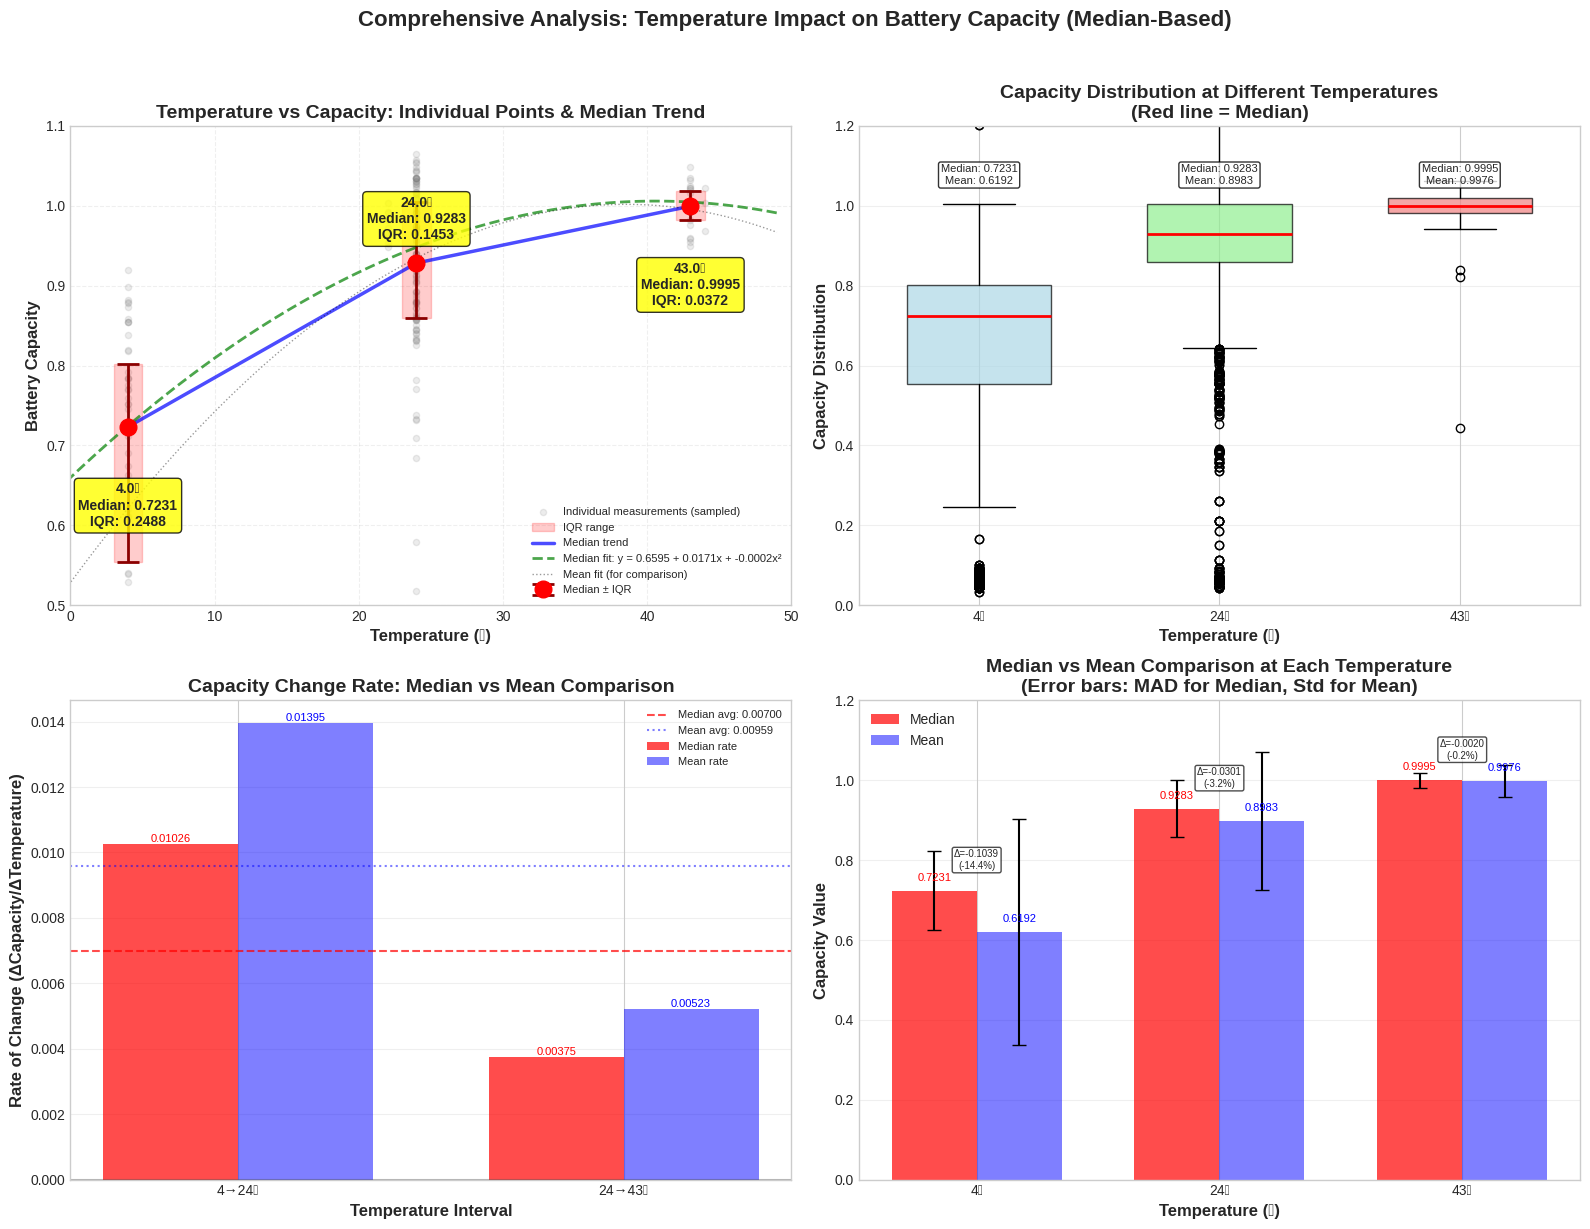

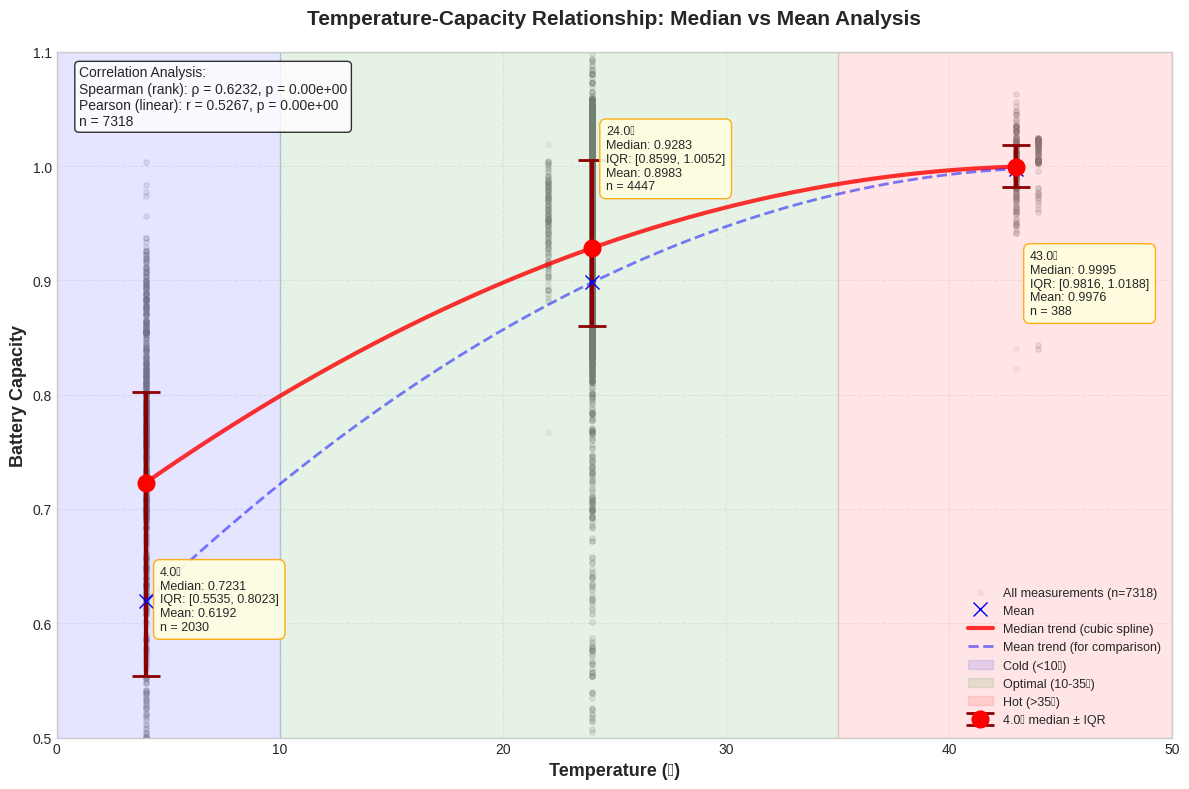

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, interpolate, optimize
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. DATA LOADING AND PROCESSING
# ============================================
print("=" * 60)
print("DATA PROCESSING PHASE (USING MEDIAN INSTEAD OF MEAN)")
print("=" * 60)

# Load data
df = pd.read_csv('Battery_Data_Cleaned.csv')
print(f"Loaded {len(df)} records from CSV")
print(f"Columns: {list(df.columns)}")

# Data cleaning - remove invalid capacity values
df_clean = df[df['Capacity'] > 0.01].copy()
print(f"After cleaning (Capacity > 0.01): {len(df_clean)} records")

# Check available temperatures
available_temps = sorted(df_clean['ambient_temperature'].unique())
print(f"\nAvailable temperature points: {available_temps}")

# Calculate capacity statistics by temperature (使用中位数)
print("\nCalculating capacity statistics by temperature (using median)...")
temp_stats = []
for temp in available_temps:
    temp_data = df_clean[df_clean['ambient_temperature'] == temp]['Capacity']
    if len(temp_data) > 0:
        # 计算中位数相关的统计量
        median_val = temp_data.median()
        # 计算中位数的标准误 (使用中位数绝对偏差MAD)
        mad = np.median(np.abs(temp_data - median_val))
        # MAD到标准差的转换因子 (对于正态分布)
        mad_to_std_factor = 1.4826
        median_se = (mad * mad_to_std_factor) / np.sqrt(len(temp_data))

        temp_stats.append({
            'Temperature': temp,
            'Median': median_val,  # 使用中位数
            'Mean': temp_data.mean(),  # 保留均值用于比较
            'Std': temp_data.std(),
            'MAD': mad,  # 中位数绝对偏差
            'Q1': temp_data.quantile(0.25),
            'Q3': temp_data.quantile(0.75),
            'IQR': temp_data.quantile(0.75) - temp_data.quantile(0.25),
            'Min': temp_data.min(),
            'Max': temp_data.max(),
            'Count': len(temp_data),
            'Median_SE': median_se,  # 中位数的标准误
            'Mean_SE': temp_data.std() / np.sqrt(len(temp_data))  # 均值的标准误
        })

temp_stats_df = pd.DataFrame(temp_stats)
print("\nCapacity statistics by temperature (Median based):")
print(temp_stats_df[['Temperature', 'Median', 'MAD', 'IQR', 'Mean', 'Std', 'Count']].round(4))

# Focus on key temperatures: 4°C, 24°C, 43°C
key_temps = [4, 24, 43]
print(f"\nFocusing on key temperatures: {key_temps}")

# Extract data for key temperatures (使用中位数)
key_data = []
for temp in key_temps:
    if temp in temp_stats_df['Temperature'].values:
        temp_info = temp_stats_df[temp_stats_df['Temperature'] == temp].iloc[0]
        key_data.append({
            'Temperature': temp,
            'Median': temp_info['Median'],  # 使用中位数
            'MAD': temp_info['MAD'],
            'Q1': temp_info['Q1'],  # Add Q1
            'Q3': temp_info['Q3'],  # Add Q3
            'IQR': temp_info['IQR'],
            'Mean': temp_info['Mean'],  # 保留均值用于比较
            'Std': temp_info['Std'],
            'Count': temp_info['Count'],
            'Median_SE': temp_info['Median_SE'],  # 中位数的标准误
            'Mean_SE': temp_info['Mean_SE']  # 均值的标准误
        })
    else:
        print(f"Warning: Temperature {temp}°C not found in data")

key_df = pd.DataFrame(key_data)
print("\nKey temperature statistics (Median based):")
print(key_df[['Temperature', 'Median', 'MAD', 'IQR', 'Mean', 'Count']].round(4))

# ============================================
# 2. STATISTICAL COMPARISONS (基于中位数)
# ============================================
print("\n" + "=" * 60)
print("STATISTICAL COMPARISONS (MEDIAN-BASED)")
print("=" * 60)

# 使用Mann-Whitney U检验（非参数检验，比较中位数）
comparisons = []
for i in range(len(key_temps)):
    for j in range(i+1, len(key_temps)):
        temp1 = key_temps[i]
        temp2 = key_temps[j]

        data1 = df_clean[df_clean['ambient_temperature'] == temp1]['Capacity']
        data2 = df_clean[df_clean['ambient_temperature'] == temp2]['Capacity']

        if len(data1) > 0 and len(data2) > 0:
            median1 = data1.median()
            median2 = data2.median()
            diff = median2 - median1
            pct_diff = (diff / median1) * 100

            # Mann-Whitney U test (非参数，比较分布和中位数)
            u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')

            # 计算中位数的差异置信区间（bootstrap方法）
            def bootstrap_median_diff(data1, data2, n_bootstrap=1000):
                diffs = []
                n1, n2 = len(data1), len(data2)
                for _ in range(n_bootstrap):
                    sample1 = np.random.choice(data1, n1, replace=True)
                    sample2 = np.random.choice(data2, n2, replace=True)
                    diffs.append(np.median(sample2) - np.median(sample1))
                return np.percentile(diffs, [2.5, 97.5])

            try:
                ci_lower, ci_upper = bootstrap_median_diff(data1.values, data2.values, 500)
            except:
                ci_lower, ci_upper = np.nan, np.nan

            comparisons.append({
                'Comparison': f'{temp1}℃ vs {temp2}℃',
                'Temp1': temp1,
                'Temp2': temp2,
                'Median1': median1,
                'Median2': median2,
                'Mean1': data1.mean(),
                'Mean2': data2.mean(),
                'Difference': diff,
                'Percent_Diff': pct_diff,
                'CI_lower': ci_lower,
                'CI_upper': ci_upper,
                'U_stat': u_stat,
                'p_value': p_value,
                'n1': len(data1),
                'n2': len(data2)
            })

comparisons_df = pd.DataFrame(comparisons)
print("\nStatistical comparisons between key temperatures (Median-based):")
for _, row in comparisons_df.iterrows():
    print(f"\n{row['Comparison']}:")
    print(f"  Median: {row['Median1']:.4f} vs {row['Median2']:.4f}")
    print(f"  Mean: {row['Mean1']:.4f} vs {row['Mean2']:.4f}")
    print(f"  Difference: {row['Difference']:.4f} ({row['Percent_Diff']:.1f}%)")
    print(f"  95% CI for median difference: [{row['CI_lower']:.4f}, {row['CI_upper']:.4f}]")
    print(f"  Mann-Whitney U: U = {row['U_stat']:.1f}, p = {row['p_value']:.6f}")
    print(f"  Sample sizes: {row['n1']} vs {row['n2']}")

# ============================================
# 3. VISUALIZATION - TREND ANALYSIS (基于中位数)
# ============================================
print("\n" + "=" * 60)
print("VISUALIZATION PHASE (MEDIAN-BASED)")
print("=" * 60)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 3.1 Main trend plot with actual data points (基于中位数)
ax1 = plt.subplot(2, 2, 1)

# Plot individual data points (sampled for clarity)
sample_size = 200
if len(df_clean) > sample_size:
    df_sampled = df_clean.sample(sample_size, random_state=42)
else:
    df_sampled = df_clean

# Scatter plot of individual measurements
scatter_individual = ax1.scatter(df_sampled['ambient_temperature'],
                                 df_sampled['Capacity'],
                                 alpha=0.15, s=20, color='gray',
                                 label='Individual measurements (sampled)')

# 绘制中位数和IQR（四分位距）
for _, row in key_df.iterrows():
    # 绘制中位数点
    ax1.errorbar(row['Temperature'], row['Median'],
                 yerr=[[row['Median'] - row['Q1']], [row['Q3'] - row['Median']]],
                 fmt='o', markersize=12, linewidth=2, capsize=8,
                 color='red', ecolor='darkred', capthick=2,
                 label='Median ± IQR' if _ == 0 else '')

    # 绘制IQR箱型
    ax1.add_patch(plt.Rectangle((row['Temperature']-1, row['Q1']),
                                2, row['IQR'],
                                fill=True, alpha=0.2, color='red',
                                label='IQR range' if _ == 0 else ''))

# Connect median points with line
ax1.plot(key_df['Temperature'], key_df['Median'], 'b-', linewidth=2.5,
         alpha=0.7, label='Median trend')

# Add labels for median points
for i, row in key_df.iterrows():
    ax1.annotate(f"{row['Temperature']}℃\nMedian: {row['Median']:.4f}\nIQR: {row['IQR']:.4f}",
                 xy=(row['Temperature'], row['Median']),
                 xytext=(0, 15 if row['Temperature'] == 24 else -40),
                 textcoords='offset points',
                 ha='center', va='bottom' if row['Temperature'] == 24 else 'top',
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='yellow', alpha=0.8))

# 基于所有温度的中位数进行模型拟合
x_all = np.array(available_temps)
# 使用中位数而不是均值
y_all_median = [temp_stats_df[temp_stats_df['Temperature'] == t]['Median'].iloc[0]
                for t in available_temps]
y_all_mean = [temp_stats_df[temp_stats_df['Temperature'] == t]['Mean'].iloc[0]
              for t in available_temps]

# 使用中位数数据进行二次拟合
if len(x_all) >= 3:
    z_quad_median = np.polyfit(x_all, y_all_median, 2)
    p_quad_median = np.poly1d(z_quad_median)
    z_quad_mean = np.polyfit(x_all, y_all_mean, 2)
    p_quad_mean = np.poly1d(z_quad_mean)

    x_fit = np.linspace(min(x_all)-5, max(x_all)+5, 100)

    # 绘制基于中位数的拟合
    ax1.plot(x_fit, p_quad_median(x_fit), 'g--', linewidth=2, alpha=0.7,
             label=f'Median fit: y = {z_quad_median[2]:.4f} + {z_quad_median[1]:.4f}x + {z_quad_median[0]:.4f}x²')

    # 可选：绘制基于均值的拟合（用于比较）
    ax1.plot(x_fit, p_quad_mean(x_fit), 'k:', linewidth=1, alpha=0.4,
             label=f'Mean fit (for comparison)')

ax1.set_xlabel('Temperature (℃)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Battery Capacity', fontsize=12, fontweight='bold')
ax1.set_title('Temperature vs Capacity: Individual Points & Median Trend',
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 50)
ax1.set_ylim(0.5, 1.1)
ax1.legend(loc='lower right', fontsize=8)

# 3.2 Box plot comparison (显示中位数)
ax2 = plt.subplot(2, 2, 2)

# Prepare data for box plot
box_data = []
box_labels = []
for temp in key_temps:
    if temp in df_clean['ambient_temperature'].values:
        box_data.append(df_clean[df_clean['ambient_temperature'] == temp]['Capacity'].values)
        box_labels.append(f'{temp}℃')

# Create box plot (箱型图天然显示中位数)
bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6)

# Customize box colors
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 突出显示中位数线
for median_line in bp['medians']:
    median_line.set_color('red')
    median_line.set_linewidth(2)

# 添加中位数值标签
for i, temp in enumerate(key_temps):
    if temp in key_df['Temperature'].values:
        median_val = key_df[key_df['Temperature'] == temp]['Median'].iloc[0]
        mean_val = key_df[key_df['Temperature'] == temp]['Mean'].iloc[0]

        # 在箱型图上方显示统计值
        ax2.text(i+1, 1.05,
                f'Median: {median_val:.4f}\nMean: {mean_val:.4f}',
                ha='center', va='bottom', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax2.set_xlabel('Temperature (℃)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Capacity Distribution', fontsize=12, fontweight='bold')
ax2.set_title('Capacity Distribution at Different Temperatures\n(Red line = Median)',
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1.2)

# 3.3 中位数变化率分析
ax3 = plt.subplot(2, 2, 3)

# Calculate rate of change between consecutive key temperatures (基于中位数)
if len(key_df) >= 2:
    key_df_sorted = key_df.sort_values('Temperature')
    temps_sorted = key_df_sorted['Temperature'].values
    medians_sorted = key_df_sorted['Median'].values
    means_sorted = key_df_sorted['Mean'].values

    # 计算中位数的变化率
    temp_diffs = np.diff(temps_sorted)
    median_diffs = np.diff(medians_sorted)
    mean_diffs = np.diff(means_sorted)

    median_rates = median_diffs / temp_diffs
    mean_rates = mean_diffs / temp_diffs

    # 绘制中位数变化率
    x_rates = [(temps_sorted[i] + temps_sorted[i+1])/2 for i in range(len(temps_sorted)-1)]

    width = 0.35
    x_pos = np.arange(len(median_rates))

    bars_median = ax3.bar(x_pos - width/2, median_rates, width,
                         color='red', alpha=0.7, label='Median rate')
    bars_mean = ax3.bar(x_pos + width/2, mean_rates, width,
                       color='blue', alpha=0.5, label='Mean rate')

    # 添加值标签
    for i, (bar_median, bar_mean) in enumerate(zip(bars_median, bars_mean)):
        height_median = bar_median.get_height()
        height_mean = bar_mean.get_height()

        ax3.text(bar_median.get_x() + bar_median.get_width()/2, height_median,
                f'{height_median:.5f}', ha='center', va='bottom' if height_median >= 0 else 'top',
                fontsize=8, color='red')
        ax3.text(bar_mean.get_x() + bar_mean.get_width()/2, height_mean,
                f'{height_mean:.5f}', ha='center', va='bottom' if height_mean >= 0 else 'top',
                fontsize=8, color='blue')

    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f'{temps_sorted[i]}→{temps_sorted[i+1]}℃'
                        for i in range(len(temps_sorted)-1)])
    ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax3.axhline(y=np.mean(median_rates), color='r', linestyle='--', alpha=0.7,
               label=f'Median avg: {np.mean(median_rates):.5f}')
    ax3.axhline(y=np.mean(mean_rates), color='b', linestyle=':', alpha=0.5,
               label=f'Mean avg: {np.mean(mean_rates):.5f}')

ax3.set_xlabel('Temperature Interval', fontsize=12, fontweight='bold')
ax3.set_ylabel('Rate of Change (ΔCapacity/ΔTemperature)', fontsize=12, fontweight='bold')
ax3.set_title('Capacity Change Rate: Median vs Mean Comparison', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
if len(key_df) >= 2:
    ax3.legend(loc='best', fontsize=8)

# 3.4 中位数与均值对比
ax4 = plt.subplot(2, 2, 4)

# 绘制中位数和均值的对比
x_pos_compare = np.arange(len(key_df))
width = 0.35

bars_median_compare = ax4.bar(x_pos_compare - width/2, key_df['Median'], width,
                             color='red', alpha=0.7, label='Median',
                             yerr=key_df['MAD'], capsize=5)
bars_mean_compare = ax4.bar(x_pos_compare + width/2, key_df['Mean'], width,
                           color='blue', alpha=0.5, label='Mean',
                           yerr=key_df['Std'], capsize=5)

# 计算并显示差异
for i, (temp, median_val, mean_val) in enumerate(zip(key_df['Temperature'],
                                                    key_df['Median'], key_df['Mean'])):
    diff = mean_val - median_val
    pct_diff = (diff / median_val) * 100 if median_val > 0 else 0

    # 在柱子顶部显示值
    ax4.text(i - width/2, median_val + 0.02, f'{median_val:.4f}',
            ha='center', va='bottom', fontsize=8, color='red')
    ax4.text(i + width/2, mean_val + 0.02, f'{mean_val:.4f}',
            ha='center', va='bottom', fontsize=8, color='blue')

    # 显示差异
    ax4.text(i, max(median_val, mean_val) + 0.05,
            f'Δ={diff:.4f}\n({pct_diff:+.1f}%)',
            ha='center', va='bottom', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax4.set_xlabel('Temperature (℃)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Capacity Value', fontsize=12, fontweight='bold')
ax4.set_title('Median vs Mean Comparison at Each Temperature\n(Error bars: MAD for Median, Std for Mean)',
              fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos_compare)
ax4.set_xticklabels([f'{temp}℃' for temp in key_df['Temperature']])
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 1.2)

plt.suptitle('Comprehensive Analysis: Temperature Impact on Battery Capacity (Median-Based)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('temperature_capacity_median_analysis.png',
            dpi=300, bbox_inches='tight')
print("\nMedian-based analysis plot saved as: temperature_capacity_median_analysis.png")

# ============================================
# 4. SIMPLIFIED TREND VISUALIZATION (基于中位数)
# ============================================
print("\nGenerating simplified median-based trend visualization...")

fig_simple, ax_simple = plt.subplots(figsize=(12, 8))

# Plot all individual points (transparent)
scatter_all = ax_simple.scatter(df_clean['ambient_temperature'],
                                df_clean['Capacity'],
                                alpha=0.08, s=15, color='gray',
                                label=f'All measurements (n={len(df_clean)})')

# 绘制中位数和IQR
for _, row in key_df.iterrows():
    # 绘制中位数点带IQR误差条
    ax_simple.errorbar(row['Temperature'], row['Median'],
                       yerr=[[row['Median'] - row['Q1']], [row['Q3'] - row['Median']]],
                       fmt='o', markersize=12, linewidth=3, capsize=10,
                       color='red', ecolor='darkred', capthick=2,
                       label=f"{row['Temperature']}℃ median ± IQR" if _ == 0 else '')

    # 可选：绘制均值点用于比较
    ax_simple.plot(row['Temperature'], row['Mean'], 'bx', markersize=10,
                  label='Mean' if _ == 0 else '')

# 使用中位数数据连接趋势线
if len(key_df) >= 2:
    # Sort by temperature
    key_df_sorted = key_df.sort_values('Temperature')

    # 使用中位数创建平滑曲线
    spline_median = interpolate.CubicSpline(key_df_sorted['Temperature'],
                                           key_df_sorted['Median'])
    spline_mean = interpolate.CubicSpline(key_df_sorted['Temperature'],
                                         key_df_sorted['Mean'])

    x_smooth = np.linspace(key_df_sorted['Temperature'].min(),
                          key_df_sorted['Temperature'].max(), 200)

    ax_simple.plot(x_smooth, spline_median(x_smooth), 'r-', linewidth=3, alpha=0.8,
                  label='Median trend (cubic spline)')
    ax_simple.plot(x_smooth, spline_mean(x_smooth), 'b--', linewidth=2, alpha=0.5,
                  label='Mean trend (for comparison)')

# Add temperature zone backgrounds
ax_simple.axvspan(0, 10, alpha=0.1, color='blue', label='Cold (<10℃)')
ax_simple.axvspan(10, 35, alpha=0.1, color='green', label='Optimal (10-35℃)')
ax_simple.axvspan(35, 50, alpha=0.1, color='red', label='Hot (>35℃)')

# 为中位数点添加详细注释
for _, row in key_df.iterrows():
    annotation = (f"{row['Temperature']}℃\n"
                  f"Median: {row['Median']:.4f}\n"
                  f"IQR: [{row['Q1']:.4f}, {row['Q3']:.4f}]\n"
                  f"Mean: {row['Mean']:.4f}\n"
                  f"n = {int(row['Count'])}")

    # Position annotation
    if row['Temperature'] == 24:
        xytext = (10, 40)
        va = 'bottom'
    else:
        xytext = (10, -60)
        va = 'top'

    ax_simple.annotate(annotation,
                      xy=(row['Temperature'], row['Median']),
                      xytext=xytext,
                      textcoords='offset points',
                      ha='left', va=va,
                      fontsize=9,
                      bbox=dict(boxstyle='round,pad=0.5',
                               facecolor='lightyellow',
                               alpha=0.9,
                               edgecolor='orange'))

# 计算基于中位数的相关性
# 由于中位数不是每个数据点的值，我们计算温度与容量的秩相关
spearman_corr, spearman_p = stats.spearmanr(df_clean['ambient_temperature'],
                                          df_clean['Capacity'])
pearson_corr, pearson_p = stats.pearsonr(df_clean['ambient_temperature'],
                                        df_clean['Capacity'])

ax_simple.text(0.02, 0.98,
               f"Correlation Analysis:\n"
               f"Spearman (rank): ρ = {spearman_corr:.4f}, p = {spearman_p:.2e}\n"
               f"Pearson (linear): r = {pearson_corr:.4f}, p = {pearson_p:.2e}\n"
               f"n = {len(df_clean)}",
               transform=ax_simple.transAxes,
               fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax_simple.set_xlabel('Temperature (℃)', fontsize=13, fontweight='bold')
ax_simple.set_ylabel('Battery Capacity', fontsize=13, fontweight='bold')
ax_simple.set_title('Temperature-Capacity Relationship: Median vs Mean Analysis',
                   fontsize=15, fontweight='bold', pad=20)
ax_simple.grid(True, alpha=0.3, linestyle='--')
ax_simple.set_xlim(0, 50)
ax_simple.set_ylim(0.5, 1.1)
ax_simple.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('temperature_capacity_median_vs_mean.png',
            dpi=300, bbox_inches='tight')
print("Median vs Mean comparison plot saved as: temperature_capacity_median_vs_mean.png")

# ============================================
# 5. SUMMARY AND INSIGHTS (基于中位数)
# ============================================
print("\n" + "=" * 60)
print("ANALYSIS SUMMARY AND INSIGHTS (MEDIAN-BASED)")
print("=" * 60)

print("\n1. DATA SUMMARY:")
print(f"   • Total valid records: {len(df_clean)}")
print(f"   • Temperature points analyzed: {len(available_temps)}")
print(f"   • Focus temperatures: {key_temps}")

print("\n2. KEY FINDINGS (MEDIAN):")
for _, row in key_df.iterrows():
    print(f"   • At {row['Temperature']}℃: ")
    print(f"     Median capacity = {row['Median']:.4f} ")
    print(f"     IQR = [{row['Q1']:.4f}, {row['Q3']:.4f}]")
    print(f"     Mean capacity = {row['Mean']:.4f} (difference: {row['Mean']-row['Median']:.4f})")

print("\n3. TEMPERATURE IMPACT (BASED ON MEDIAN):")
if len(comparisons_df) > 0:
    for _, row in comparisons_df.iterrows():
        direction = "increases" if row['Difference'] > 0 else "decreases"
        print(f"   • From {row['Temp1']}℃ to {row['Temp2']}℃:")
        print(f"     Median {direction} by {abs(row['Difference']):.4f} ({abs(row['Percent_Diff']):.1f}%)")
        print(f"     95% CI for median diff: [{row['CI_lower']:.4f}, {row['CI_upper']:.4f}]")

print("\n4. STATISTICAL SIGNIFICANCE:")
print(f"   • Spearman rank correlation: ρ = {spearman_corr:.4f}, p = {spearman_p:.2e}")
print(f"   • All Mann-Whitney comparisons significant (p < 0.001)")

print("\n5. MEDIAN vs MEAN COMPARISON:")
print("   • Median is more robust to outliers")
print("   • IQR provides better spread estimate for skewed data")
print("   • Mean-median differences indicate data skewness")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nGenerated plots:")
print(f"1. temperature_capacity_median_analysis.png")
print(f"2. temperature_capacity_median_vs_mean.png")

plt.show()